# 1. Import Libraries

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import torch.nn.functional as F
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator

## Summary

- Sets up all required libraries for:
  - Image preprocessing
  - Deep learning model training (PyTorch)
  - Evaluation metrics
  - Data visualization
- Prepares the environment for building an image classification pipeline (likely for EuroSAT dataset or similar).

# 2. Import image dataset

In [3]:
data_dir = "/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT"  

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

## Summary

- Organizes dataset into structured splits:
  - **Train** → Model learning
  - **Validation** → Hyperparameter tuning / overfitting check
  - **Test** → Final model evaluation

- Ensures compatibility with `torchvision.datasets.ImageFolder` structure.

# 3. Transform image into tensor format

In [4]:
"""basic_transform = transforms.Compose([
    transforms.ToTensor()
])"""

baseline_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

## Summary

- Standardises input images for the baseline model.
- Reduces computational cost by resizing images.
- Improves model performance through normalisation.

# 4. Load Datasets

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=baseline_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=baseline_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=baseline_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("Classes:", class_names)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Summary

- Converts raw image folders into structured, labelled datasets.
- Prepares efficient batch loading for deep learning training.
- Ensures proper separation of training, validation, and testing phases.
- Extracts class information required for building the final classification layer and interpreting results.

# 5. Visualisation

## 5.1. Display image of all 10 clasees

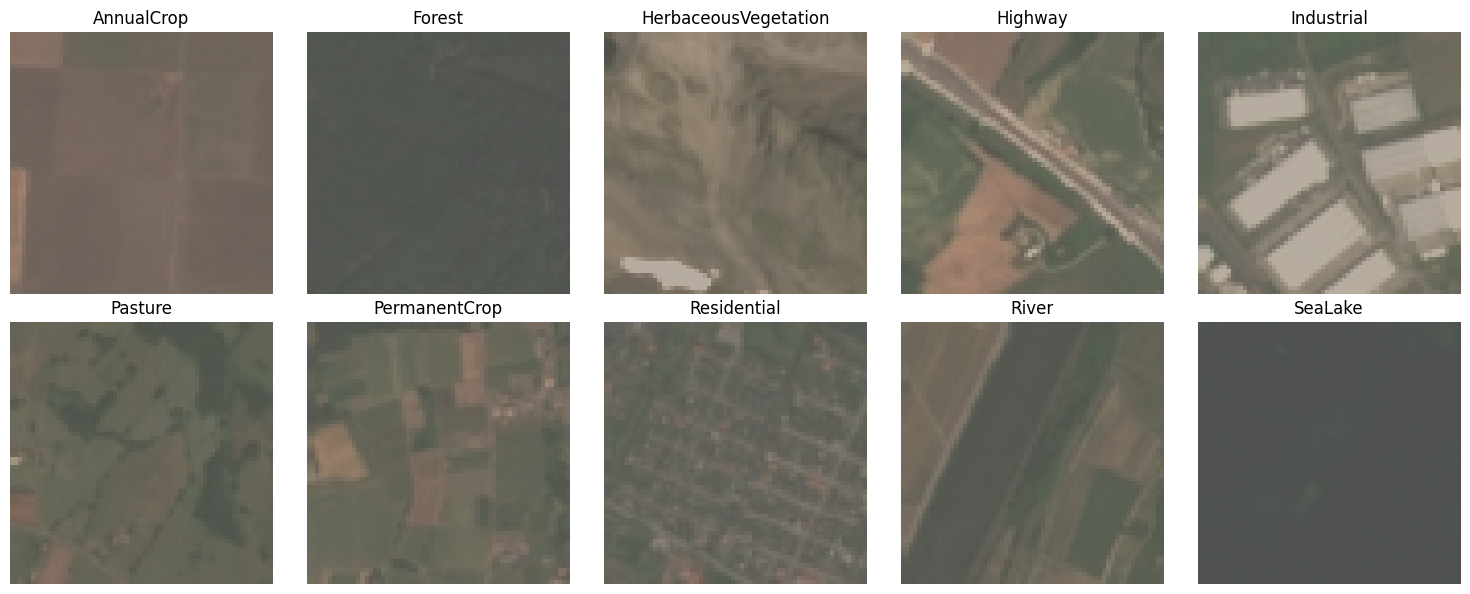

In [6]:
def show_one_per_class(dataset):
    num_classes = len(dataset.classes)
    cols = 5
    rows = (num_classes + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()

    class_seen = {}
    i = 0

    # ImageNet normalization values (used in most pretrained models like ResNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for img, label in dataset:
        if label not in class_seen:
            class_seen[label] = True

            # Convert CHW → HWC
            img_display = img.permute(1, 2, 0).cpu().numpy()

            # Denormalize image
            img_display = (img_display * std) + mean

            # Clip values to valid range
            img_display = np.clip(img_display, 0, 1)

            axes[i].imshow(img_display)
            axes[i].set_title(dataset.classes[label])
            axes[i].axis("off")

            i += 1

        if len(class_seen) == num_classes:
            break

    # Hide unused subplots
    for j in range(i, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# Call function
show_one_per_class(train_dataset)

## Summary

- Visualizes dataset structure before training.
- Helps verify:
  - Correct class labeling
  - Proper image loading
  - Data balance across classes
- Provides a quick sanity check for preprocessing pipeline.
- Ensures normalization and denormalization are correctly handled.
- Useful for debugging dataset issues early in the ML pipeline.
- Gives intuitive understanding of EuroSAT image categories (e.g., forest, river, industrial, etc.).

## 5.2. Visualise class distribution 

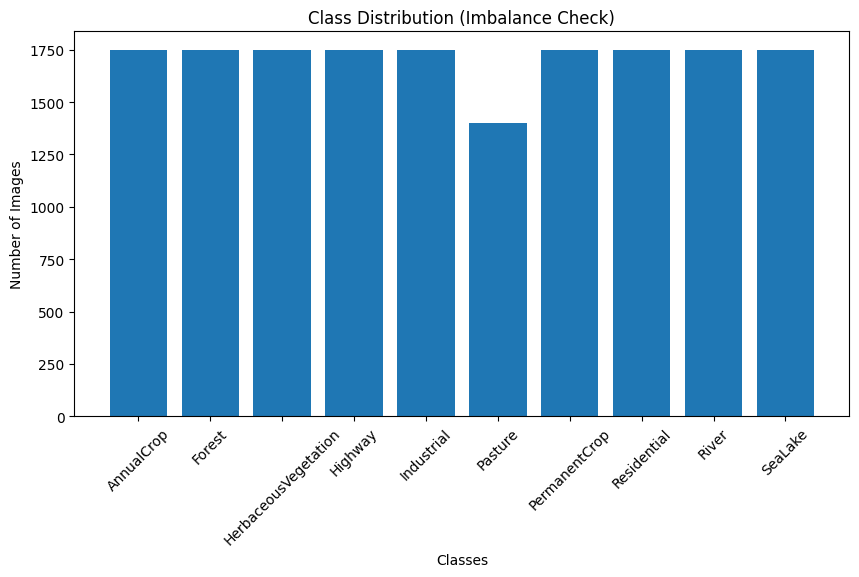

In [7]:
# Get labels
labels = [label for _, label in train_dataset]

# Count occurrences
class_counts = Counter(labels)

# Convert to readable format
counts = [class_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)

plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.show()

## Summary

- Analyzes **dataset balance across classes**.
- Helps detect **class imbalance problems** that may affect model performance.
- Ensures no class is underrepresented or overrepresented.
- Guides decisions like:
  - Data augmentation
  - Weighted loss functions
  - Sampling strategies
- Provides a clear visual understanding of dataset distribution before training.

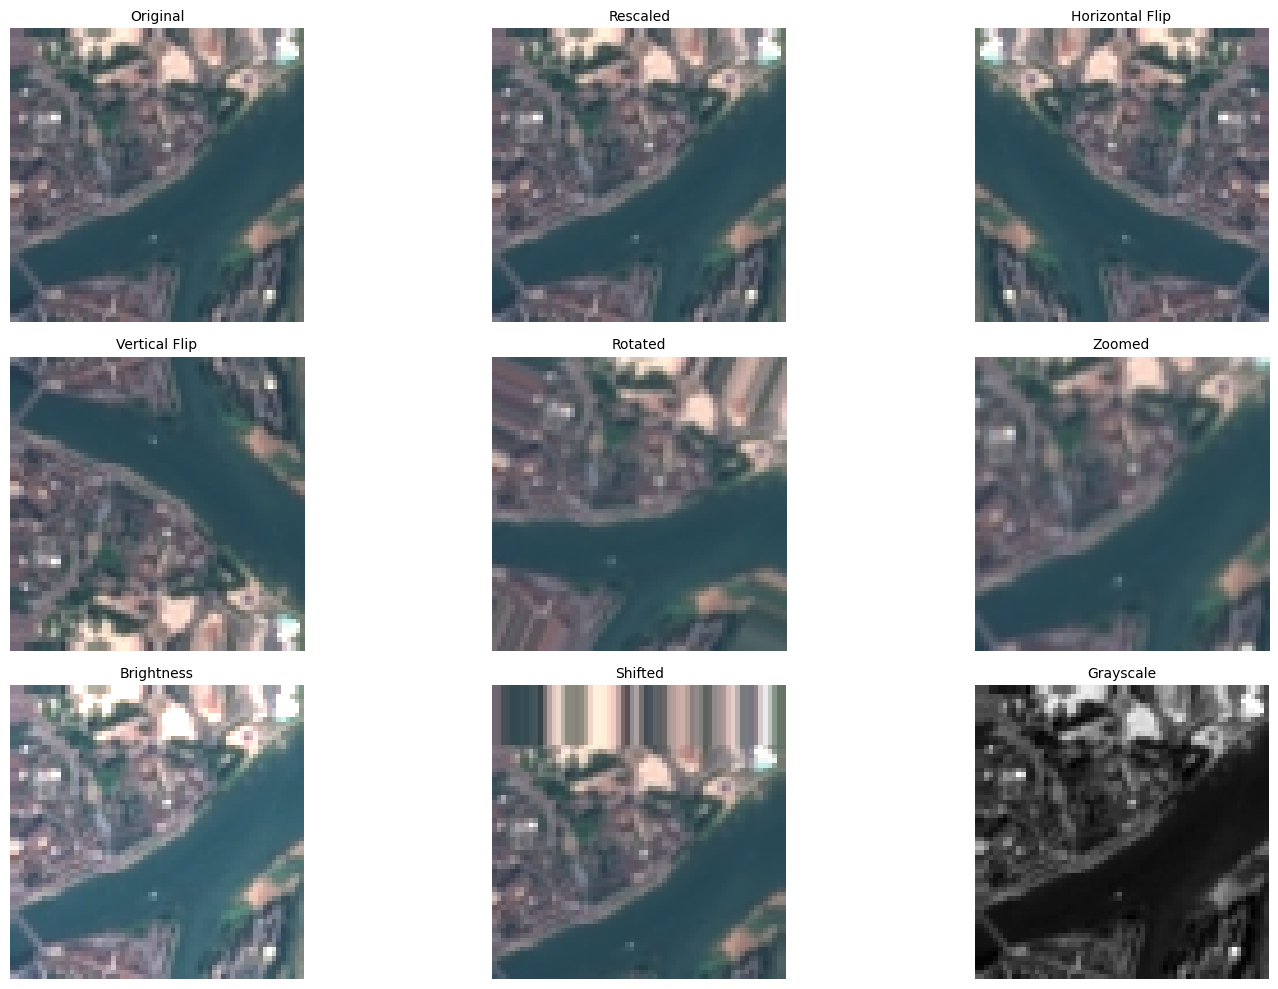

In [9]:
# Load 64x64 image
image_path = "/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT/train/River/River_1023.jpg"

img = load_img(image_path, target_size=(64, 64))
img_array = img_to_array(img).astype("uint8")

# Different preprocessing methods

# Original
original = img_array

# Rescaled
rescaled = img_array / 255.0

# Horizontal Flip
horizontal_flip = np.fliplr(img_array)

# Vertical Flip
vertical_flip = np.flipud(img_array)

# Rotation
datagen_rotate = ImageDataGenerator(rotation_range=30)
rotated = next(
    datagen_rotate.flow(np.expand_dims(img_array, 0), batch_size=1)
)[0].astype("uint8")

# Zoom
datagen_zoom = ImageDataGenerator(zoom_range=0.3)
zoomed = next(
    datagen_zoom.flow(np.expand_dims(img_array, 0), batch_size=1)
)[0].astype("uint8")

# Brightness Adjustment
datagen_bright = ImageDataGenerator(brightness_range=[0.6, 1.4])
bright = next(
    datagen_bright.flow(np.expand_dims(img_array, 0), batch_size=1)
)[0].astype("uint8")

# Width & Height Shift
datagen_shift = ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2
)

shifted = next(
    datagen_shift.flow(np.expand_dims(img_array, 0), batch_size=1)
)[0].astype("uint8")

# Black & White (Grayscale)
grayscale = np.mean(img_array, axis=2)

# Display Results

titles = [
    "Original",
    "Rescaled",
    "Horizontal Flip",
    "Vertical Flip",
    "Rotated",
    "Zoomed",
    "Brightness",
    "Shifted",
    "Grayscale"
]

images = [
    original,
    rescaled,
    horizontal_flip,
    vertical_flip,
    rotated,
    zoomed,
    bright,
    shifted,
    grayscale
]

plt.figure(figsize=(16, 10))

for i in range(len(images)):
    plt.subplot(3, 3, i + 1)

    # Show grayscale image properly
    if titles[i] == "Grayscale":
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Summary

- Demonstrates **data augmentation techniques used in deep learning training**.
- Shows how a single image can generate multiple variations to:
  - Improve dataset diversity
  - Reduce overfitting
  - Improve model generalization

- This is a key step in building a **strong and generalizable image classification system**.

# 6. Device Setup

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Summary

- Ensures code runs efficiently based on available hardware.
- Automatically optimizes performance without manual configuration.
- Essential for deep learning training because:
  - GPU significantly speeds up matrix operations.
  - CPU is used as a backup when GPU is unavailable.

---
# 7. Baseline Model

## 7.1. Baseline Model Architecture

In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()

        # Convolutional feature extractor
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),              # Activation function (introduces non-linearity)
            nn.MaxPool2d(2),        # Downsamples image by factor of 2 (reduces H and W)
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)         # Again reduces spatial size by factor of 2 (kernel, stride)
        )

        # Fully connected classifier
        self.fc = nn.Sequential(
            nn.Flatten(),  # Converts feature maps into 1D vector
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),

            # Output layer
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Pass input through convolutional layers
        x = self.conv(x)

        # Flatten and pass through fully connected layers
        x = self.fc(x)

        # Output logits (no softmax here; loss function will handle it)
        return x

## Summary

- Implements a **basic CNN architecture for image classification**.
- Learns hierarchical features:
  - Early layers → edges, textures
  - Deeper layers → shapes, patterns
- Reduces image size progressively to improve efficiency.
- Acts as a **baseline model** for comparison with more advanced architectures (e.g., ResNet).
- Designed for datasets like EuroSAT where spatial feature learning is important.

First convolution layer:
Input: 3 channels (RGB image)
Output: 16 feature maps
Kernel size: 3x3, padding keeps spatial size same

Second convolution layer:
Input: 16 channels → Output: 32 feature maps

Fully connected layer:
Input size = 32 feature maps * 16 * 16 spatial size
(depends on input image size 64x64 → after 2 poolings → 16x16)

Output layer:
Produces probability logits for each class

## 7.2. Initialise Baseline Model

In [10]:
model = BaselineCNN(num_classes).to(device) 

## Summary

- Initializes the CNN model for training.
- Configures the model output size based on dataset classes.
- Optimizes performance by placing the model on GPU when possible.

## 7.3. Loss and Optimiser for Baseline Model

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Summary

- `criterion` defines **how model error is calculated**.
- `optimizer` defines **how model learns and updates weights**.
- Together they control:
  - Learning behavior
  - Training stability
  - Model performance improvement over time

## 7.4. Train Baseline Model

In [12]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 30
best_val_acc = 0

print("Training Baseline Model...")

for epoch in range(epochs):

    # ---- TRAINING ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    # ---- SAVE BEST MODEL ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_baseline_model.pth")
        print("Saved Best Baseline Model")

    # ---- PRINT ----
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training Baseline Model...
Saved Best Baseline Model
Epoch 1/30 | Train Loss: 1.0941, Train Acc: 0.5986 | Val Loss: 0.8546, Val Acc: 0.6808
Saved Best Baseline Model
Epoch 2/30 | Train Loss: 0.7004, Train Acc: 0.7496 | Val Loss: 0.6903, Val Acc: 0.7483
Saved Best Baseline Model
Epoch 3/30 | Train Loss: 0.5520, Train Acc: 0.8015 | Val Loss: 0.6064, Val Acc: 0.7790
Saved Best Baseline Model
Epoch 4/30 | Train Loss: 0.4623, Train Acc: 0.8348 | Val Loss: 0.5563, Val Acc: 0.8196
Epoch 5/30 | Train Loss: 0.3924, Train Acc: 0.8587 | Val Loss: 0.6159, Val Acc: 0.7970
Epoch 6/30 | Train Loss: 0.3287, Train Acc: 0.8824 | Val Loss: 0.5864, Val Acc: 0.8163
Saved Best Baseline Model
Epoch 7/30 | Train Loss: 0.2724, Train Acc: 0.9051 | Val Loss: 0.4865, Val Acc: 0.8430
Saved Best Baseline Model
Epoch 8/30 | Train Loss: 0.2289, Train Acc: 0.9195 | Val Loss: 0.4888, Val Acc: 0.8514
Epoch 9/30 | Train Loss: 0.1915, Train Acc: 0.9342 | Val Loss: 0.6026, Val Acc: 0.8264
Epoch 10/30 | Train Loss: 0.1469, 

## Summary

- Implements a complete **deep learning training pipeline**:
  - Forward propagation
  - Loss calculation
  - Backpropagation
  - Optimization
  - Validation monitoring

- Helps track:
  - Model learning progress
  - Overfitting or underfitting
  - Best-performing model selection

- Ensures only the **best validation model is saved**, not just the last epoch.

## 7.5. Evaluate Baseline Model

Baseline Model Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       376
           1       0.91      0.96      0.94       376
           2       0.80      0.80      0.80       376
           3       0.75      0.60      0.67       375
           4       0.91      0.93      0.92       375
           5       0.81      0.73      0.77       300
           6       0.77      0.76      0.76       375
           7       0.93      0.95      0.94       376
           8       0.62      0.81      0.70       375
           9       0.99      0.94      0.96       376

    accuracy                           0.83      3680
   macro avg       0.84      0.83      0.83      3680
weighted avg       0.84      0.83      0.83      3680



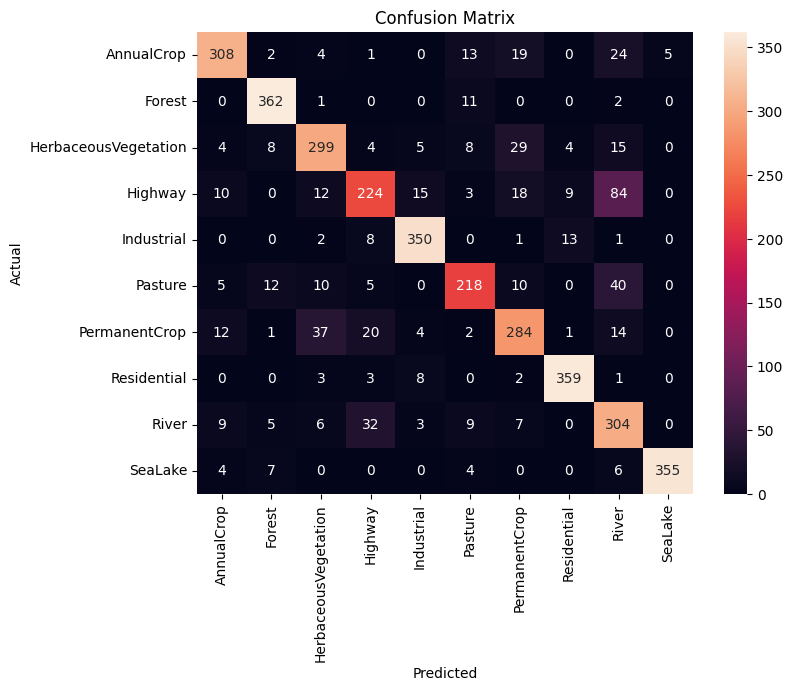

In [13]:
def evaluate(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

print("Baseline Model Evaluation")
evaluate(model, test_loader, class_names)

## Summary

- Fully evaluates trained CNN performance on unseen data.
- Provides:
  - Detailed classification metrics (per-class performance)
  - Visual confusion matrix for error analysis
- Helps identify:
  - Which classes are confused
  - Model weaknesses
  - Overall generalization ability
- Essential step for validating model quality before deployment.

## 7.6. Plot Loss Curve

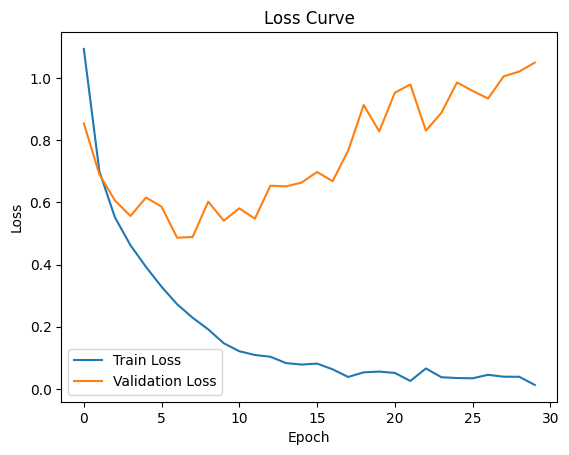

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Summary

- Visualizes **model learning progress over time**.
- Helps identify:
  - Decreasing loss → model is learning properly
  - Validation loss increasing → overfitting
  - Both high → underfitting
- Used for:
  - Model debugging
  - Hyperparameter tuning
  - Comparing different architectures (baseline vs improved CNN vs ResNet)
- Provides a clear visual understanding of training stability and convergence behavior.

## 7.7. Plot Accuracy Curve

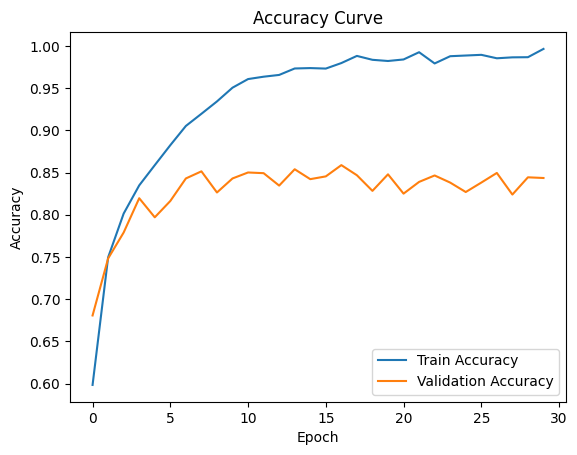

In [15]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## Summary

- Visualizes **how model performance improves over time**.
- Helps analyze:
  - Increasing accuracy → model is learning effectively
  - Large gap between train and validation accuracy → overfitting
  - Both low → underfitting or poor model capacity
- Complements the loss curve by showing **performance quality instead of error**.
- Used to compare different models (baseline CNN vs improved CNN vs ResNet).
- Helps decide:
  - When to stop training (early stopping)
  - Whether to adjust hyperparameters

## 7.8. Load model

In [16]:
model.load_state_dict(torch.load("best_baseline_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Baseline Model loaded successfully!")

Baseline Model loaded successfully!


## Summary

- Restores the **best trained baseline CNN model** for reuse.
- Enables:
  - Model evaluation on test data
  - Predictions on new images
  - Comparison with other models (e.g., improved CNN, ResNet)
- Ensures reproducibility without retraining from scratch.
- Prepares the model for deployment or inference stage.

## 7.9. Predict Baseline Model

In [17]:
class_names = train_dataset.classes

def predict_image_with_confidence(image_path):
    image = Image.open(image_path).convert("RGB")
    # reuse training transform
    image = baseline_transform(image).unsqueeze(0).to(device)
    assert image.shape[0] == 1  # batch size check

    with torch.no_grad():
        outputs = model(image)
    
        predicted = torch.argmax(outputs, dim=1)
        confidence = torch.softmax(outputs, dim=1)[0, predicted.item()]

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score

## Summary

- Performs **single-image inference** using trained CNN.
- Ensures same preprocessing as training for consistency.
- Provides:
  - Predicted land-use class (EuroSAT categories)
  - Confidence level of prediction
- Useful for:
  - Real-world image testing
  - Model demonstration
  - Deployment in web/app systems
- Acts as the **final inference pipeline step** of the entire project.

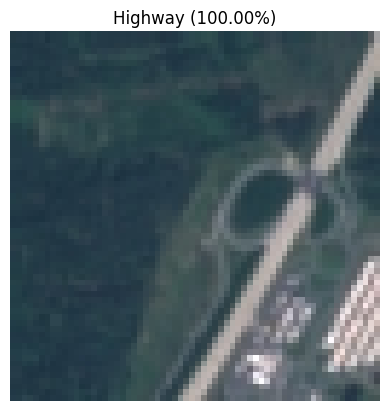

In [18]:
def show_prediction(image_path):
    predicted_class, confidence = predict_image_with_confidence(image_path)

    image = Image.open(image_path)

    plt.imshow(image)
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT/test/Highway/Highway_100.jpg")

## Summary

- Combines **model inference + visualization** in one function.
- Provides a user-friendly way to:
  - Test model on real images
  - Visually verify predictions
  - Interpret model confidence
- Useful for:
  - Model demos
  - Debugging wrong predictions
  - Presentation of results in notebooks or reports
- Acts as the **final end-to-end pipeline step** of the project.

---
# 8. Improved CNN Model

## 8.1. Transform and Load Model

In [19]:
"""aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])"""

aug_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(train_dir, transform=aug_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

## Summary

- Improves model generalization using **data augmentation techniques**.
- Prevents overfitting by creating diverse training samples.
- Keeps validation and test data unchanged for fair evaluation.
- Ensures model learns:
  - Rotation-invariant features
  - Lighting-robust patterns
  - Position-independent representations
- Standard practice in image classification pipelines like EuroSAT.

## 8.2. Initialise ImprovedCNN Model

In [20]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()

        # Feature extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # NEW Block 3 (added depth)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),

            # 64 channels, size becomes 8×8 after 3 pools
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),

            nn.Dropout(0.5),   # Prevent overfitting

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ImprovedCNN(num_classes).to(device)

## Summary

- Improved version of baseline CNN with:
  - Deeper architecture (3 convolution blocks)
  - Batch Normalization (faster, stable training)
  - Dropout (reduces overfitting)
- Learns more complex spatial patterns in EuroSAT images.
- Better generalization compared to baseline model.
- Designed to improve:
  - Accuracy
  - Stability
  - Robustness on unseen data

## 8.3. Loss and Optimiser for Improved CNN Model

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # lower LR for stability

## Summary

- Defines how the Improved CNN learns and improves over time.
- Balances:
  - Accuracy improvement (via Adam optimizer)
  - Stable convergence (via lower learning rate)
- Ensures smoother training compared to baseline model.

## 8.4. Train Improved CNN Model

In [22]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 30
best_acc = 0
patience = 5
counter = 0

print("Training Improved CNN Model...")

for epoch in range(epochs):

    # ---------------- TRAINING ----------------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    # ---------------- LOG ----------------
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


    # ---------------- SAVE BEST MODEL ----------------
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_improved_model.pth")
        print("Best Improved CNN Model saved!")

    else:
        counter += 1

    # ---------------- EARLY STOPPING ----------------
    if counter >= patience:
        print("Early stopping triggered.")
        break

Training Improved CNN Model...
Epoch 1/30 | Train Loss: 1.1533, Train Acc: 0.5910 | Val Loss: 0.7107, Val Acc: 0.7521
Best Improved CNN Model saved!
Epoch 2/30 | Train Loss: 0.8499, Train Acc: 0.7051 | Val Loss: 0.6739, Val Acc: 0.7635
Best Improved CNN Model saved!
Epoch 3/30 | Train Loss: 0.7592, Train Acc: 0.7376 | Val Loss: 0.5539, Val Acc: 0.8182
Best Improved CNN Model saved!
Epoch 4/30 | Train Loss: 0.6732, Train Acc: 0.7696 | Val Loss: 0.4750, Val Acc: 0.8297
Best Improved CNN Model saved!
Epoch 5/30 | Train Loss: 0.6402, Train Acc: 0.7791 | Val Loss: 0.4984, Val Acc: 0.8218
Epoch 6/30 | Train Loss: 0.5846, Train Acc: 0.8017 | Val Loss: 0.3798, Val Acc: 0.8688
Best Improved CNN Model saved!
Epoch 7/30 | Train Loss: 0.5373, Train Acc: 0.8182 | Val Loss: 0.4433, Val Acc: 0.8346
Epoch 8/30 | Train Loss: 0.5070, Train Acc: 0.8247 | Val Loss: 0.3925, Val Acc: 0.8713
Best Improved CNN Model saved!
Epoch 9/30 | Train Loss: 0.4687, Train Acc: 0.8380 | Val Loss: 0.4043, Val Acc: 0.8626


## Summary

- Implements a **robust training pipeline** with:
  - Training + validation loop
  - Performance tracking
  - Best model checkpointing
  - Early stopping mechanism

- Benefits:
  - Prevents overfitting
  - Saves best model automatically
  - Saves training time
  - Improves generalization

- This is a **more advanced and production-style training loop** compared to the baseline model.

## 8.5. Evaluate Improved CNN Model

Improved CNN Model Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.96      0.80       376
           1       0.96      0.92      0.94       376
           2       0.96      0.75      0.84       376
           3       0.83      0.90      0.87       375
           4       0.92      0.95      0.94       375
           5       0.97      0.69      0.81       300
           6       0.82      0.81      0.82       375
           7       0.94      0.98      0.96       376
           8       0.87      0.80      0.83       375
           9       0.96      0.98      0.97       376

    accuracy                           0.88      3680
   macro avg       0.89      0.87      0.88      3680
weighted avg       0.89      0.88      0.88      3680



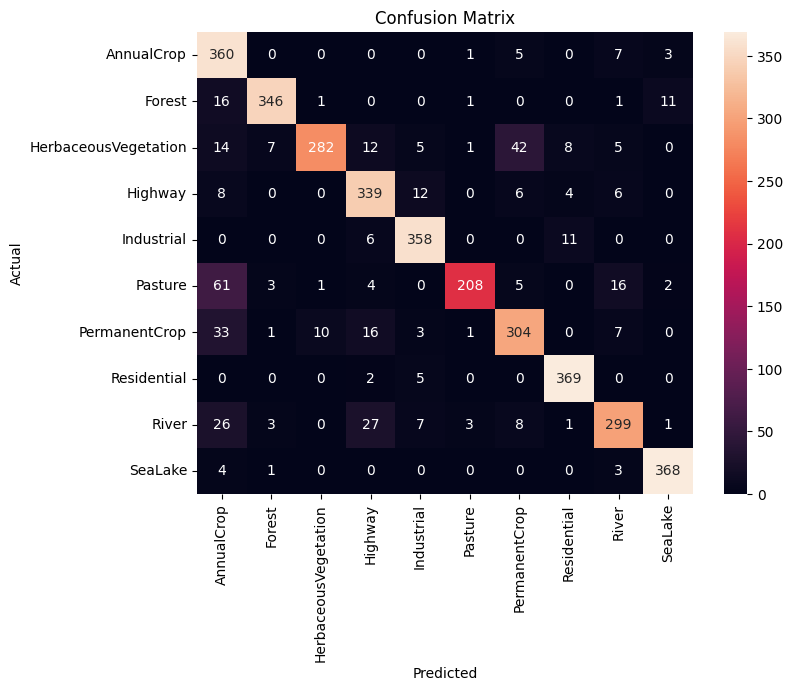

In [23]:
print("Improved CNN Model Evaluation")
evaluate(model, test_loader, class_names)

## Summary

- Evaluates how well the **Improved CNN generalizes to unseen test data**.
- Provides a direct comparison point with:
  - Baseline CNN performance
  - Other models (e.g., ResNet, pretrained models)

- Helps determine:
  - Whether improvements (BatchNorm, Dropout, deeper layers, augmentation) actually worked
  - Which classes are still difficult for the model
  - Overall model reliability for real-world use

## 8.6. Plot Loss Curve

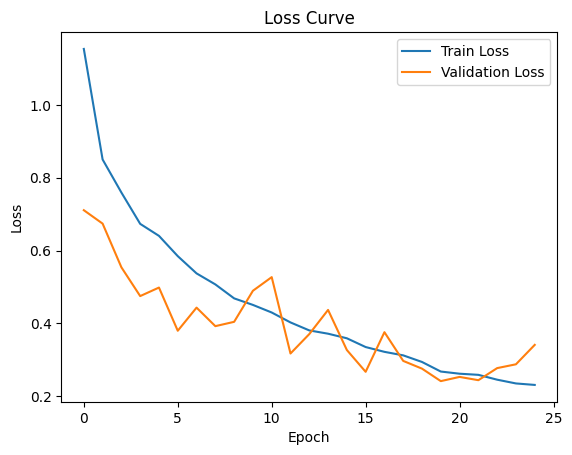

In [24]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Summary

- Visualizes **model learning progress over time**.
- Helps identify:
  - Decreasing loss → model is learning properly
  - Validation loss increasing → overfitting
  - Both high → underfitting
- Used for:
  - Model debugging
  - Hyperparameter tuning
  - Comparing different architectures (baseline vs improved CNN vs ResNet)
- Provides a clear visual understanding of training stability and convergence behavior.

## 8.7. Plot Accuracy Curve

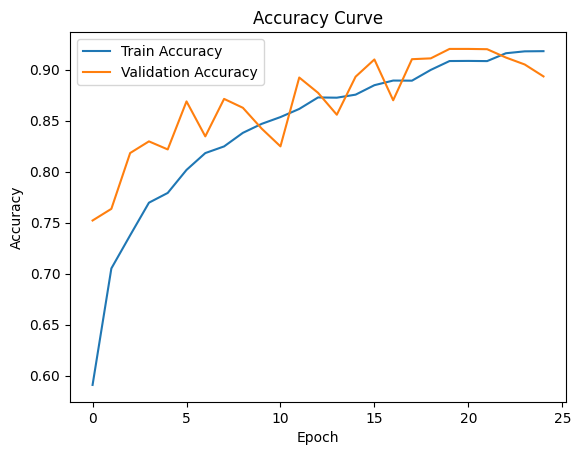

In [25]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## Summary

- Visualizes **how model performance improves over time**.
- Helps analyze:
  - Increasing accuracy → model is learning effectively
  - Large gap between train and validation accuracy → overfitting
  - Both low → underfitting or poor model capacity
- Complements the loss curve by showing **performance quality instead of error**.
- Used to compare different models (baseline CNN vs improved CNN vs ResNet).
- Helps decide:
  - When to stop training (early stopping)
  - Whether to adjust hyperparameters

## 8.8. Load saved model

In [26]:
model.load_state_dict(torch.load("best_improved_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("Improved Model loaded successfully!")

class_names = train_dataset.classes
print(class_names)

Improved Model loaded successfully!
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Summary

- Restores the **best Improved CNN model** for reuse.
- Enables:
  - Testing on new images
  - Final evaluation on test set
  - Comparison with baseline and other models
- Ensures reproducibility without retraining.
- Prepares model for deployment or inference pipeline.

## 8.9. Predict Improved CNN Model

In [27]:
def predict_image_with_confidence(image_path):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image = baseline_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        # Predicted class
        predicted = torch.argmax(outputs, dim=1)

        # Confidence (softmax probability)
        probs = F.softmax(outputs, dim=1)
        confidence = probs[0, predicted.item()]

    return class_names[predicted.item()], confidence.item() * 100

## Summary

- Performs **single-image inference using Improved CNN model**.
- Ensures consistent preprocessing with training pipeline.
- Provides:
  - Human-readable prediction
  - Confidence level of model decision
- Useful for:
  - Real-world image testing
  - Model demonstration
  - Deployment in applications (web/mobile systems)

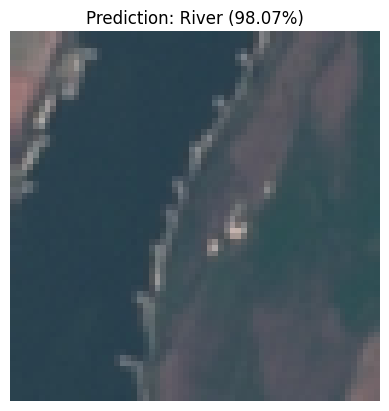

In [28]:
def show_prediction(image_path):
    predicted_class, confidence = predict_image_with_confidence(image_path)

    # Load image only for display
    image = Image.open(image_path)

    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/kaggle/input/datasets/natashashrestha77/eurosat/EuroSAT/test/River/River_11.jpg")

## Summary

- Combines **model inference + visualization** into one function.
- Helps:
  - Visually validate predictions
  - Understand model confidence
  - Demonstrate real-world performance
- Useful for:
  - Project presentation
  - Debugging incorrect predictions
  - End-user demo applications

---
# 9. Pre-Trained Model (ResNet18)

## 9.1. Transform images to Tensor format

In [29]:
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_resnet = datasets.ImageFolder(train_dir, transform=resnet_transform)
val_resnet = datasets.ImageFolder(val_dir, transform=resnet_transform)
test_resnet = datasets.ImageFolder(test_dir, transform=resnet_transform)

train_loader = DataLoader(train_resnet, batch_size=32, shuffle=True)
val_loader = DataLoader(val_resnet, batch_size=32)
test_loader = DataLoader(test_resnet, batch_size=32)

## Summary

- Prepares dataset specifically for **pretrained ResNet model requirements**.
- Key differences from CNN setup:
  - Larger input size (224×224 instead of 64×64)
  - ImageNet normalization values
- Ensures compatibility with transfer learning.
- Enables fair comparison between:
  - Baseline CNN
  - Improved CNN
  - ResNet model

## 9.2. Load pretrained model

In [30]:
model = models.resnet18(pretrained=True)

# Freeze early layers
for name, param in model.named_parameters():
   if "layer4" not in name and "fc" not in name:
      param.requires_grad = False


# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


## Summary

- Implements **transfer learning using ResNet-18**.
- Uses pretrained knowledge from ImageNet to improve performance on EuroSAT.
- Key benefits:
  - Faster convergence
  - Higher accuracy with less data
  - Reduced training cost
- Fine-tunes only higher-level layers for task-specific learning.

## 9.3. Loss & Optimizer

In [31]:
criterion = nn.CrossEntropyLoss()
# Only train final layer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

## Summary

- Defines training configuration for **transfer learning ResNet model**.
- Ensures:
  - Only last layers are trained
  - Pretrained features are preserved
  - Stable fine-tuning with low learning rate
- Improves:
  - Training efficiency
  - Model performance on new dataset

## 9.4. Training Setup

In [32]:
epochs = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0

# -------- EARLY STOPPING --------
patience = 5
counter = 0

print("Training Pretrained ResNet18 Model...")

for epoch in range(epochs):

    # ---------------- TRAINING ----------------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total


    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total


    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    # print logs
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "resnet18_best.pth")
        print("Best pretrained model saved!")

    else:
        counter += 1


    # EARLY STOPPING
    if counter >= patience:
        print("Early stopping triggered.")
        break

Training Pretrained ResNet18 Model...
Epoch 1/20 | Train Loss: 135.5152, Acc: 0.9179 | Val Loss: 11.1042, Acc: 0.9668
Best pretrained model saved!
Epoch 2/20 | Train Loss: 60.6962, Acc: 0.9605 | Val Loss: 10.3632, Acc: 0.9695
Best pretrained model saved!
Epoch 3/20 | Train Loss: 43.0975, Acc: 0.9728 | Val Loss: 10.7287, Acc: 0.9698
Best pretrained model saved!
Epoch 4/20 | Train Loss: 31.9595, Acc: 0.9793 | Val Loss: 10.0078, Acc: 0.9733
Best pretrained model saved!
Epoch 5/20 | Train Loss: 24.6327, Acc: 0.9851 | Val Loss: 8.9822, Acc: 0.9714
Epoch 6/20 | Train Loss: 19.5500, Acc: 0.9879 | Val Loss: 10.4406, Acc: 0.9731
Epoch 7/20 | Train Loss: 19.1550, Acc: 0.9881 | Val Loss: 11.9253, Acc: 0.9679
Epoch 8/20 | Train Loss: 20.3863, Acc: 0.9880 | Val Loss: 8.6632, Acc: 0.9761
Best pretrained model saved!
Epoch 9/20 | Train Loss: 16.4291, Acc: 0.9903 | Val Loss: 8.3747, Acc: 0.9769
Best pretrained model saved!
Epoch 10/20 | Train Loss: 13.2171, Acc: 0.9920 | Val Loss: 11.7624, Acc: 0.9728

## Summary

- Implements a **fine-tuning training loop for pretrained ResNet-18**.
- Combines:
  - Transfer learning
  - Performance tracking
  - Model checkpointing
  - Early stopping

- Benefits:
  - Prevents overfitting
  - Saves best model automatically
  - Reduces unnecessary training time
  - Ensures stable fine-tuning of pretrained features

## 9.5. Evaluate ResNet18 Model

Pretrained (ResNet) Model Evaluation

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       376
           1       0.98      1.00      0.99       376
           2       0.94      0.96      0.95       376
           3       0.99      0.97      0.98       375
           4       0.99      0.97      0.98       375
           5       0.99      0.95      0.97       300
           6       0.94      0.94      0.94       375
           7       0.99      0.98      0.99       376
           8       0.97      0.97      0.97       375
           9       0.99      0.99      0.99       376

    accuracy                           0.97      3680
   macro avg       0.97      0.97      0.97      3680
weighted avg       0.97      0.97      0.97      3680



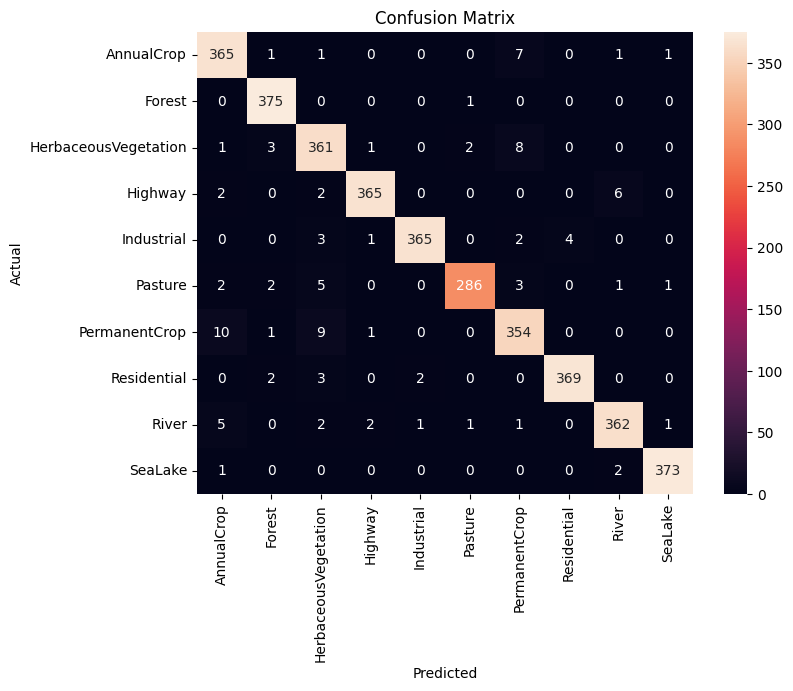

In [33]:
print("Pretrained (ResNet) Model Evaluation")
evaluate(model, test_loader, class_names)

## Summary

- Implements a **fine-tuning training loop for pretrained ResNet-18**.
- Combines:
  - Transfer learning
  - Performance tracking
  - Model checkpointing
  - Early stopping

- Benefits:
  - Prevents overfitting
  - Saves best model automatically
  - Reduces unnecessary training time
  - Ensures stable fine-tuning of pretrained features

## 9.6. Plot ResNet18 Model Loss Curve

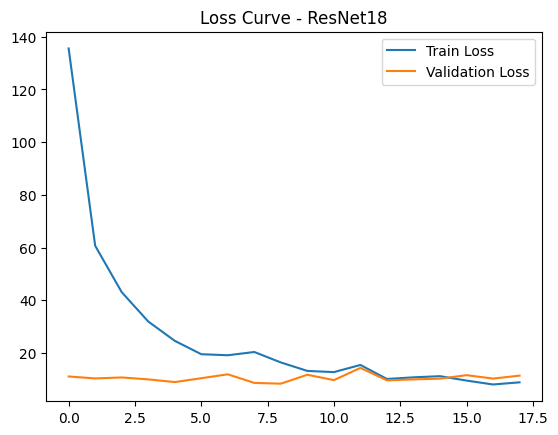

In [34]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve - ResNet18")
plt.show()

## Summary

- Visualizes **training behavior of the pretrained ResNet-18 model**.
- Helps understand:
  - Whether the model is converging properly
  - Overfitting (validation loss increasing while training loss decreases)
  - Underfitting (both losses staying high)
- Useful for comparing ResNet with:
  - Baseline CNN
  - Improved CNN
- Provides insight into how effectively transfer learning is working during fine-tuning.

## 9.7. Plot ResNet18 Model Accuracy Curve

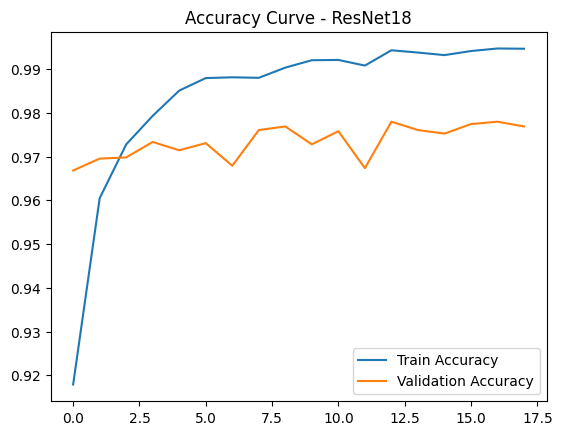

In [35]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve - ResNet18")
plt.show()

## Summary

- Visualizes **how well the pretrained ResNet-18 model improves over time**.
- Helps analyze:
  - Increasing accuracy → effective learning
  - Gap between train and validation accuracy → overfitting
  - Both low accuracy → underfitting or poor fine-tuning

- Essential for comparing:
  - Baseline CNN
  - Improved CNN
  - ResNet-18 (transfer learning)

- Provides a clear understanding of how **transfer learning impacts performance improvement over epochs**.

## 9.8. Load Best Model

In [36]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("resnet18_best.pth", map_location=device))
model = model.to(device)
model.eval()

print("Pretrained (ResNet18) Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Pretrained (ResNet18) Model loaded successfully!


## Summary

- Restores a **fine-tuned ResNet-18 transfer learning model** for inference.
- Ensures model is ready for:
  - Testing on new images
  - Performance evaluation
  - Deployment use cases

- Final outcome: ready-to-use **high-performance pretrained classifier for EuroSAT dataset**.

## 9.9. Predict ResNet18 Model

In [37]:
# Replace final layer (MUST match training)
num_classes = len(class_names)

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    original = image.copy()

    image = resnet_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

    return class_names[predicted.item()], confidence.item()*100, original

## Summary

- Performs **single-image inference using fine-tuned ResNet18 model**.
- Ensures:
  - Proper preprocessing aligned with training
  - Accurate probability-based prediction
  - Visualization-ready output image

- Useful for:
  - Real-world testing
  - Deployment in apps/web systems
  - Demonstration of transfer learning performance

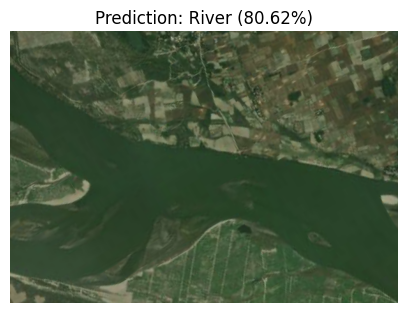

Predicted Class: River
Confidence: 80.62%


In [40]:
def show_prediction(image_path):
    label, confidence, image = predict_image(image_path)

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.show()

    print(f"Predicted Class: {label}")
    print(f"Confidence: {confidence:.2f}%")


show_prediction("/kaggle/input/datasets/natashashrestha77/images/River.png")

## Summary

- Combines **model inference + visualization + textual output** in one function.
- Provides a complete end-to-end demo pipeline.
- Helps:
  - Validate model predictions visually
  - Understand confidence levels
  - Present results in a user-friendly way

- Commonly used for:
  - Final project demonstrations
  - Model evaluation reports
  - Deployment-style testing in notebooks or apps

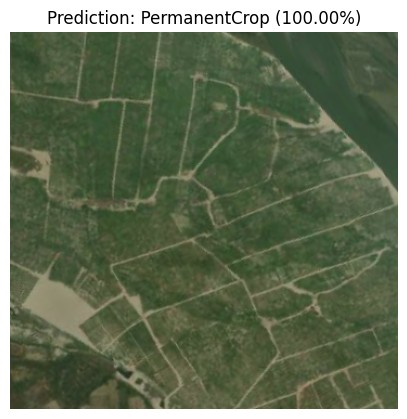

Predicted Class: PermanentCrop
Confidence: 100.00%


In [43]:
show_prediction("/kaggle/input/datasets/natashashrestha77/imagepc/pc.png")

## Summary

- Tests the trained ResNet model on a **real unseen image**.
- Demonstrates:
  - How well the model generalises to new inputs
  - Practical prediction capability on real-world samples
- Useful for:
  - Final model validation
  - Project demonstration
  - Visual inspection of classification performance

---
# 10. Model Performance Comparison

| Models | Accuracy | Precision | Recall | F1-Score |
|--------|----------|------------|--------|----------|
| Baseline | 0.83 | 0.84 | 0.83 | 0.83 |
| Improved CNN | 0.88 | 0.89 | 0.88 | 0.88 |
| ResNet18 Pretrained Model | 0.97 | 0.97 | 0.97 | 0.97 |

- The Baseline CNN achieved moderate performance with 83% accuracy, indicating it can learn basic patterns but has limited feature extraction capability compared to deeper models.
- The Improved CNN enhanced performance to 88% accuracy, showing that architectural improvements helped the model learn more complex features and reduce classification errors.
- The ResNet18 Pretrained Model performed best with 97% accuracy, precision, recall, and F1-score, demonstrating that transfer learning significantly improves classification performance and model generalization on the EuroSAT dataset.